In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Lets load the California House Price Dataset

In [6]:
from sklearn.datasets import fetch_california_housing

In [7]:
california=fetch_california_housing()

In [8]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [9]:
## check the description of this dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [10]:
print(california.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [11]:
print(california.target_names)

['MedHouseVal']


## Preparing the dataset

In [12]:
dataset=pd.DataFrame(california.data, columns=california.feature_names)

In [22]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
## add the target label
dataset['Price']=california.target

In [14]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
## Descriptive Statistics
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [17]:
## check the missing values
dataset.isnull()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


In [18]:
## check the missing values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [19]:
## EDA - Exploratory Data Analysis
## Correlation
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [20]:
## heatmap visuallization
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [21]:
corr=dataset.corr()

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,
           annot=True, # show correlation for each cell
           fmt=".2f",  # format 2 decimal 
           cmap="coolwarm",
           square=True,
           linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout
plt.show

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

## Analyze the details of correlation

In [23]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


Text(0, 0.5, 'House Price')

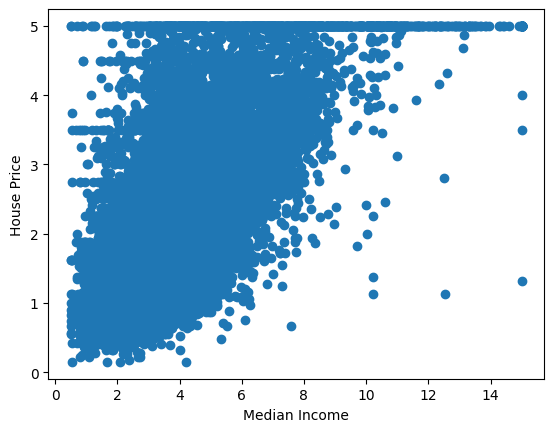

In [24]:
plt.scatter(dataset['MedInc'],dataset['Price'])
plt.xlabel("Median Income")
plt.ylabel("House Price")

In [25]:
sns.regplot(x="MedInc", y="Price", data=dataset)

NameError: name 'sns' is not defined

## Extract the independent and dependent features for training

In [26]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [27]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [28]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

In [29]:
## train text split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=24)

In [52]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8796,10.0600,22.0,7.985201,1.047569,2808.0,2.968288,33.77,-118.41
13139,4.9516,3.0,7.338559,1.159015,16305.0,3.043113,38.43,-121.44
17624,5.2000,10.0,5.043296,1.121508,1599.0,2.233240,37.26,-121.95
14912,3.8615,26.0,4.993610,0.913738,1145.0,3.658147,32.61,-117.05
15504,6.6170,14.0,7.108481,0.998028,3097.0,3.054241,33.08,-117.25
...,...,...,...,...,...,...,...,...
6500,2.3611,52.0,2.360000,0.786667,269.0,3.586667,34.07,-118.04
19857,1.6645,20.0,5.671815,1.169884,1031.0,3.980695,36.35,-119.42
14528,3.8140,6.0,4.169837,1.019022,1541.0,2.093750,32.92,-117.14
899,4.7135,28.0,4.950749,1.062099,1344.0,2.877944,37.54,-121.97


In [53]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
3950,5.7613,23.0,6.296748,1.101626,1486.0,3.020325,34.20,-118.62
3113,4.1500,11.0,5.500933,1.061567,2728.0,2.544776,35.62,-117.66
10347,7.1497,21.0,6.755245,0.930070,860.0,3.006993,33.61,-117.66
6971,3.4312,52.0,6.359909,1.050114,1177.0,2.681093,33.99,-118.03
10940,1.5026,10.0,3.326642,1.076642,2176.0,3.970803,33.75,-117.88
...,...,...,...,...,...,...,...,...
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
13389,3.5186,4.0,4.555874,1.134670,3359.0,2.406160,34.10,-117.58
12840,2.7179,35.0,4.876344,0.986559,1076.0,2.892473,38.66,-121.43
8471,4.2083,33.0,5.026163,1.151163,1073.0,3.119186,33.91,-118.32


In [54]:
y_train

8796     5.00001
13139    1.53700
17624    2.48700
14912    1.39300
15504    2.85200
          ...   
6500     1.31300
19857    0.48000
14528    1.32500
899      2.03200
12706    1.18800
Name: Price, Length: 14448, dtype: float64

In [55]:
y_test

3950     2.358
3113     0.857
10347    2.740
6971     2.438
10940    1.518
         ...  
4        3.422
13389    1.278
12840    0.811
8471     1.805
18165    3.622
Name: Price, Length: 6192, dtype: float64

In [30]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [31]:
X_train=scaler.fit_transform(X_train)

In [32]:
X_test=scaler.transform(X_test)

In [33]:
import pickle
pickle.dump(scaler, open("scaling.pkl", "wb"))

In [59]:
X_train

array([[ 3.24831585, -0.52675682,  0.98835733, ..., -0.01072026,
        -0.8730514 ,  0.58012567],
       [ 0.56464502, -2.03616254,  0.73830405, ..., -0.00431488,
         1.31434743, -0.93767494],
       [ 0.69514064, -1.4800657 , -0.14926332, ..., -0.07364331,
         0.76515073, -1.19314633],
       ...,
       [-0.03298711, -1.79783532, -0.48702583, ..., -0.08558424,
        -1.27204045,  1.21629952],
       [ 0.43956045, -0.05010238, -0.18505066, ..., -0.018454  ,
         0.89658242, -1.20316482],
       [-0.71078683, -0.52675682, -0.31356863, ..., -0.08628192,
         1.39414524, -0.91262873]])

In [60]:
X_test

array([[ 0.99001662, -0.44731441,  0.33544059, ..., -0.00626562,
        -0.67120987,  0.47493156],
       [ 0.14352871, -1.40062329,  0.02770264, ..., -0.04697456,
        -0.00466345,  0.95581888],
       [ 1.71940519, -0.60619923,  0.51273913, ..., -0.00740691,
        -0.94815522,  0.95581888],
       ...,
       [-0.60881742,  0.50599446, -0.21382287, ..., -0.01721028,
         1.42230918, -0.9326657 ],
       [ 0.17415631,  0.34710965, -0.15588869, ...,  0.00219727,
        -0.80733555,  0.62520885],
       [ 1.05127181, -0.92396885, -0.10568929, ..., -0.04746947,
         0.80739663, -1.22821103]])

## Model Training

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
regression=LinearRegression()

In [63]:
regression.fit(X_train, y_train)

LinearRegression()

In [64]:
## print the results
print(regression.coef_)

[ 0.81572979  0.12392163 -0.24609871  0.29162261 -0.00196596 -0.04443433
 -0.9151091  -0.8854355 ]


In [65]:
print(regression.intercept_)

2.0677199550110728


In [66]:
## get the information of models
regression.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [67]:
## Prediction of Test Data
reg_pred=regression.predict(X_test)

In [68]:
reg_pred

array([2.93455785, 1.14241925, 3.19583184, ..., 1.14887356, 2.5088699 ,
       3.1631385 ])

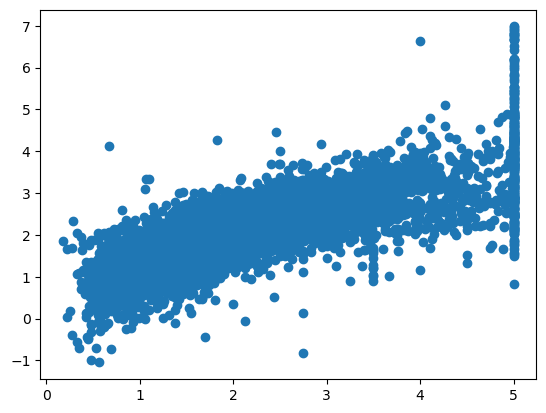

In [69]:
## plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)

In [70]:
## compute the residuals
residuals=y_test-reg_pred

In [71]:
residuals

3950    -0.576558
3113    -0.285419
10347   -0.455832
6971     0.421930
10940    0.407949
           ...   
4        0.986155
13389   -0.273995
12840   -0.337874
8471    -0.703870
18165    0.458862
Name: Price, Length: 6192, dtype: float64

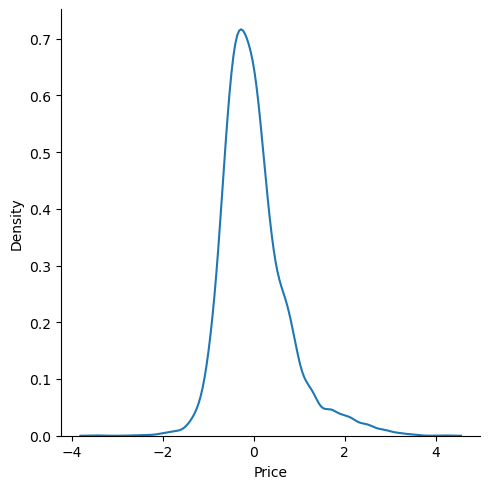

In [72]:
## plot this residuals

sns.displot(residuals, kind="kde")

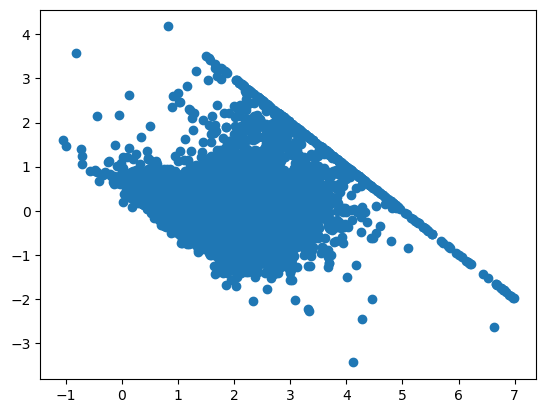

In [73]:
## check the homogenity of residuals
plt.scatter(reg_pred, residuals)

In [77]:
## performance metric
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

0.527843337097182
0.517862557431139
0.719626679210227


## R-squared and adjust R-squared


Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination;
SSR	=	sum of squares of residuals;
SST	=	total sum of squares;

In [78]:
from sklearn.metrics import r2_score
score = r2_score(y_test, reg_pred)
print(score)

0.6095793409857658


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model;
n: The number of observations;
k: The number of predictor variables;

In [79]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6090741872946589

## New Data Prediction

In [80]:
california.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [85]:
california.data[0].shape

(8,)

In [88]:
california.data[0].reshape(1,-1).shape

(1, 8)

In [ ]:
## error when dont use the normalization

In [90]:
regression.predict(california.data[0].reshape(1,-1))

array([85.33525692])

In [93]:
## Normalization for new data
scaler.transform(california.data[0].reshape(1,-1))

C:\Users\nuilab\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.33694787,  0.9826489 ,  0.6012468 , -0.14270943, -0.95981194,
        -0.0460518 ,  1.05617804, -1.33340513]])

In [94]:
regression.predict(scaler.transform(california.data[0].reshape(1,-1)))

C:\Users\nuilab\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.12428537])

## Pickling the Model File for Deployment

In [96]:
import pickle

In [100]:
pickle.dump(regression, open('regmodel.pkl', 'wb'))

In [101]:
pickle_model=pickle.load(open('regmodel.pkl','rb'))

In [ ]:
## precdict with pickle file


In [102]:
pickle_model.predict(scaler.transform(california.data[0].reshape(1,-1)))

C:\Users\nuilab\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.12428537])